# 🚗 Car Market Segmentation — Unsupervised Clustering

## 📌 Project Overview

Car manufacturers, dealerships, and analysts often want to understand 
how vehicles naturally group together based on their specs and pricing — 
without predefined categories like "economy" or "luxury." Rather than 
relying on manual labels, we can let the data itself reveal these 
groupings.

In this project, we apply **K-Means clustering**, an unsupervised 
learning technique, to a dataset of ~12,000 U.S. car models 
(1990–2018), using features like price (MSRP), horsepower, fuel 
efficiency, and engine specs to uncover natural market segments.

---

## 🎯 Objective

Group cars into distinct segments based on their specifications and 
price, **without using any predefined labels**, then interpret what 
characterizes each resulting group (e.g., "high-power luxury," 
"budget-efficient compacts," "family SUVs").

---

## 🔑 Key Difference From Supervised Learning

Unlike our previous regression and classification projects, this 
project has **no target variable**. There's nothing to predict and no 
"correct answer" to check against. Instead of a train/test split and 
accuracy scores, we:

- Skip the train/test split entirely — clustering uses the full 
  dataset, since there's no prediction to validate against unseen data
- Judge success through **cluster separation and interpretability**, 
  using tools like the Elbow Method and Silhouette Score, rather than 
  accuracy or F1
- Focus on **describing and understanding** the groups the algorithm 
  finds, rather than predicting a known outcome

---

## 🗺️ Project Roadmap

1. **Data Collection** — car specs and pricing data via the Kaggle API
2. **Data Cleaning** — handle missing values, duplicates, and 
   inconsistent entries
3. **Exploratory Data Analysis** — understand distributions of price, 
   horsepower, MPG, and other specs
4. **Feature Scaling** — critical for K-Means, since it's a 
   distance-based algorithm sensitive to feature magnitude
5. **Finding Optimal K** — Elbow Method and Silhouette Score to decide 
   how many clusters best fit the data
6. **Fitting K-Means** — assign each car to a cluster
7. **Visualizing Clusters** — scatter plots and dimensionality 
   reduction (PCA) to see the groupings
8. **Profiling Clusters** — describe what makes each segment distinct 
   (e.g., average price, power, size, common vehicle styles)

---

## 📊 Data Source

This project uses the **Car Features and MSRP** dataset from Kaggle, 
containing car listings from 1990–2018, including make, model, engine 
specs, MPG, vehicle category, and MSRP.

> Source: [Car Features and MSRP — Kaggle](https://www.kaggle.com/datasets/CooperUnion/cardataset)

#### 📥 Loading the Dataset

We read the located CSV into a pandas DataFrame — this is our raw, 
unprocessed dataset, straight from the Kaggle download.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn jupyterlab nbconvert kagglehub sweetviz joblib setuptools watermark -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ==========================================
# 1. DATA MANIPULATION & VISUALIZATION
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sweetviz as sv
import os
import kagglehub
import logging
import warnings
from sweetviz import FeatureConfig

warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ==========================================
# 2. PREPROCESSING & PIPELINES
# ==========================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

# ==========================================
# 3. CLUSTERING & EVALUATION
# ==========================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

c:\Users\LarTI\OneDrive\Desktop\Projects\car_clustering_kmeans\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the watermark extension to log the environment state
%reload_ext watermark

# Display professional metadata tracking our data engineering stack (NO SPACES after commas)
%watermark -a "Maykon - Car Market Segmentation 🚗" -d -u -v -p pandas,numpy,matplotlib,seaborn,scikit-learn,kagglehub,jupyterlab,nbconvert,sweetviz,joblib,yellowbrick,watermark,setuptools

Author: Maykon - Car Market Segmentation 🚗

Last updated: 2026-08-31

Python implementation: CPython
Python version       : 3.13.7
IPython version      : 9.16.1

pandas      : 3.0.5
numpy       : 2.5.2
matplotlib  : 3.11.1
seaborn     : 0.13.2
scikit-learn: 1.9.0
kagglehub   : 1.0.2
jupyterlab  : 4.6.3
nbconvert   : 7.17.1
sweetviz    : 2.3.3
joblib      : 1.5.3
yellowbrick : 1.5
watermark   : 2.6.0
setuptools  : 84.0.0



> OBS: This project was built with assistance from Claude (Anthropic) for 
> code review, debugging, and explanation throughout the notebook.

In [4]:
# --- AUTOMATED KAGGLE INGESTION ---
# Download the latest version of the car features and MSRP(Manufacturer's Suggested Retail Price) dataset
path = kagglehub.dataset_download("CooperUnion/cardataset")
print("🚀 Path to dataset files:", path)

🚀 Path to dataset files: C:\Users\LarTI\.cache\kagglehub\datasets\CooperUnion\cardataset\versions\1


In [5]:
# --- LOCATING AND READING THE CSV ---
# List out all files inside the downloaded repository path to spot the target file
all_files = os.listdir(path)
print("📂 Files discovered in directory:", all_files)

# Filter out all CSV files dynamically
csv_files = [file for file in all_files if file.endswith('.csv')]

if len(csv_files) == 0:
    raise FileNotFoundError("❌ Critical Error: No CSV files found in the downloaded folder!")
else:
    # Grab the primary CSV file found
    csv_filename = csv_files[0]
    full_csv_path = os.path.join(path, csv_filename)
    print(f"🎯 Target CSV located: {csv_filename}")

📂 Files discovered in directory: ['data.csv']
🎯 Target CSV located: data.csv


In [6]:
# Ingest the dataset into a pandas DataFrame
df = pd.read_csv(full_csv_path)
print(f"✅ Dataset successfully loaded! Named 'df', Shape: {df.shape[0]} rows, {df.shape[1]} columns.")

✅ Dataset successfully loaded! Named 'df', Shape: 11914 rows, 16 columns.


In [7]:
# Display the first 5 records to see our column properties and labels
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [8]:
df.shape # (rows, columns)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 11914
Number of columns: 16


In [9]:
df.sample(15) # Random 15 rows

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
5693,HUMMER,H3,2008,regular unleaded,242.0,5.0,MANUAL,four wheel drive,4.0,Luxury,Midsize,4dr SUV,18,13,130,30995
246,Nissan,300ZX,1995,regular unleaded,222.0,6.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,22,17,2009,3101
11282,Toyota,Venza,2014,regular unleaded,268.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Performance",Midsize,Wagon,25,18,2031,35080
1315,Suzuki,Aerio,2006,regular unleaded,155.0,4.0,AUTOMATIC,front wheel drive,4.0,NaN,Compact,Wagon,28,22,481,15499
2114,Volvo,C70,2012,premium unleaded (recommended),227.0,5.0,AUTOMATIC,front wheel drive,2.0,Luxury,Compact,Convertible,28,18,870,40450
6098,Volkswagen,Jetta,2015,diesel,150.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Diesel,Midsize,Sedan,45,31,873,25175
11209,Aston Martin,Vanquish,2015,premium unleaded (required),568.0,12.0,AUTOMATIC,rear wheel drive,2.0,"Exotic,High-Performance",Midsize,Coupe,21,13,259,283695
7576,Toyota,Pickup,1994,regular unleaded,116.0,4.0,MANUAL,rear wheel drive,2.0,NaN,Compact,Extended Cab Pickup,25,19,2031,2000
4599,Ford,F-250,1997,regular unleaded,220.0,8.0,MANUAL,four wheel drive,3.0,NaN,Large,Extended Cab Pickup,17,12,5657,3215
11877,GMC,Yukon,2017,flex-fuel (unleaded/E85),355.0,8.0,AUTOMATIC,four wheel drive,4.0,"Flex Fuel,Performance",Large,4dr SUV,22,16,549,51530


In [10]:
df.tail() #Displays the last 5 rows of the DataFrame df.

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920
11913,Lincoln,Zephyr,2006,regular unleaded,221.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Midsize,Sedan,26,17,61,28995


In [11]:
df.dtypes #Displays the data type of each column in the DataFrame.

Make                     str
Model                    str
Year                   int64
Engine Fuel Type         str
Engine HP            float64
Engine Cylinders     float64
Transmission Type        str
Driven_Wheels            str
Number of Doors      float64
Market Category          str
Vehicle Size             str
Vehicle Style            str
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

In [12]:
df.columns #Returns a list (Index object) containing the names of all columns in the DataFrame.

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

### 🧹 Data Preprocessing & Hygiene

In [13]:
df.isna().sum() # Count missing values per column

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

#### 🏷️ Handling `Market Category` Missing Values

`Market Category` is missing in ~31% of rows — too large a portion to 
safely impute with a guessed value (e.g., most-frequent), since that 
would fabricate a substantial chunk of the dataset. Instead, we label 
missing entries explicitly as `'Unknown'`, treating "no category listed" 
as its own honest, meaningful value rather than pretending to know 
something we don't.

All other missing values (`Engine Fuel Type`, `Engine HP`, 
`Engine Cylinders`, `Number of Doors`) are small (under 0.6% each) and 
will be handled automatically inside the preprocessing pipeline via 
`SimpleImputer`.

In [14]:
df['Market Category'] = df['Market Category'].fillna('Unknown')

In [15]:
df.describe(include='number').T #Generates a complete statistical summary of the DataFrame.

,count,mean,std,min,25%,50%,75%,max
Year,11914.0,2010.384338,7.579740,1990.0,2007.0,2015.0,2016.00,2017.0
Engine HP,11845.0,249.386070,109.191870,55.0,170.0,227.0,300.00,1001.0
Engine Cylinders,11884.0,5.628829,1.780559,0.0,4.0,6.0,6.00,16.0
Number of Doors,11908.0,3.436093,0.881315,2.0,2.0,4.0,4.00,4.0
highway MPG,11914.0,26.637485,8.863001,12.0,22.0,26.0,30.00,354.0
city mpg,11914.0,19.733255,8.987798,7.0,16.0,18.0,22.00,137.0
Popularity,11914.0,1554.911197,1441.855347,2.0,549.0,1385.0,2009.00,5657.0
MSRP,11914.0,40594.737032,60109.103604,2000.0,21000.0,29995.0,42231.25,2065902.0


In [16]:
df.info() #Displays a summary of the DataFrame structure.

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    11914 non-null  str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [17]:
df.dtypes # This command displays the data types of each column in the DataFrame df.

Make                     str
Model                    str
Year                   int64
Engine Fuel Type         str
Engine HP            float64
Engine Cylinders     float64
Transmission Type        str
Driven_Wheels            str
Number of Doors      float64
Market Category          str
Vehicle Size             str
Vehicle Style            str
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

In [18]:
print("Number of duplicate rows before dropping:", df.duplicated().sum())
df.drop_duplicates(inplace=True) # Remove duplicate rows from the DataFrame df.
print("Number of duplicate rows after dropping:", df.duplicated().sum()) # After dropping duplicates, check again to confirm that there are no duplicate rows remaining in the DataFrame df.

Number of duplicate rows before dropping: 715
Number of duplicate rows after dropping: 0


In [19]:
# ============================================================
# 🧹 COLUMN NAME SANITIZATION
# ============================================================
print("❓Original columns:" + str(df.columns.tolist()))
print()

df.columns = (
    df.columns
    .str.lower()                                        # lowercase everything
    .str.strip()                                        # remove leading/trailing whitespace
    .str.replace(r"[^a-z0-9]+", "_", regex=True)       # replace anything not a letter/number with _
    .str.strip("_")                                     # remove leading/trailing underscores
)

print("✅ Columns sanitized:" + str(df.columns.tolist()))

❓Original columns:['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']

✅ Columns sanitized:['make', 'model', 'year', 'engine_fuel_type', 'engine_hp', 'engine_cylinders', 'transmission_type', 'driven_wheels', 'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style', 'highway_mpg', 'city_mpg', 'popularity', 'msrp']


#### 🧹 Outlier Filtering & Data Hygiene

Unsupervised clustering with K-Means relies heavily on **Euclidean Distance**, making it extremely sensitive to extreme numerical outliers and data entry errors. 

Rather than allowing extreme values to distort feature scaling (`StandardScaler`) and pull cluster centroids away from general consumer cars, we filter out the following known anomalies:

* **Data Entry Typos:** Corrupted records such as a gas-powered Audi A6 listed with `354` highway MPG.
* **Extreme Exotic Hypercars:** Vehicles priced over **$500,000** (e.g., $2M Bugatti Veyron, $1.5M Lamborghini Reventon). These represent $<0.1\%$ of records but heavily skew price variance.
* **Electric Vehicles (EVs):** Vehicles with 0 cylinders and $>100$ MPGe (e.g., Tesla Model S, Nissan Leaf), which act as structural outliers against traditional internal combustion engines.

Filtering these ~50 extreme rows (out of ~11,000) keeps our dataset focused on standard consumer market segments.

In [20]:
# Record shape before filtering
initial_rows = df.shape[0]

# --- 1. FILTER OUTLIER ROWS ---
df_clean = df[
    (df['highway_mpg'] < 100) & 
    (df['msrp'] < 500000) & 
    (df['engine_cylinders'] > 0)
].copy()

# --- 2. DROP UNNECESSARY / HIGH-CARDINALITY COLUMNS ---
columns_to_drop = ['model', 'market_category']
df_clean.drop(columns=columns_to_drop, inplace=True)

# --- 3. SUMMARY REPORT ---
dropped_rows = initial_rows - df_clean.shape[0]
print(f"✂️ Outliers dropped: {dropped_rows} rows.")
print(f"🗑️ Columns dropped: {columns_to_drop}")
print(f"✅ Final dataset shape: {df_clean.shape[0]} rows, {df_clean.shape[1]} columns.")

✂️ Outliers dropped: 98 rows.
🗑️ Columns dropped: ['model', 'market_category']
✅ Final dataset shape: 11101 rows, 14 columns.


### 📊 Exploratory Data Analysis (EDA)

We analyze feature distributions to check for skewness and inspect pairwise correlations among numerical specs.

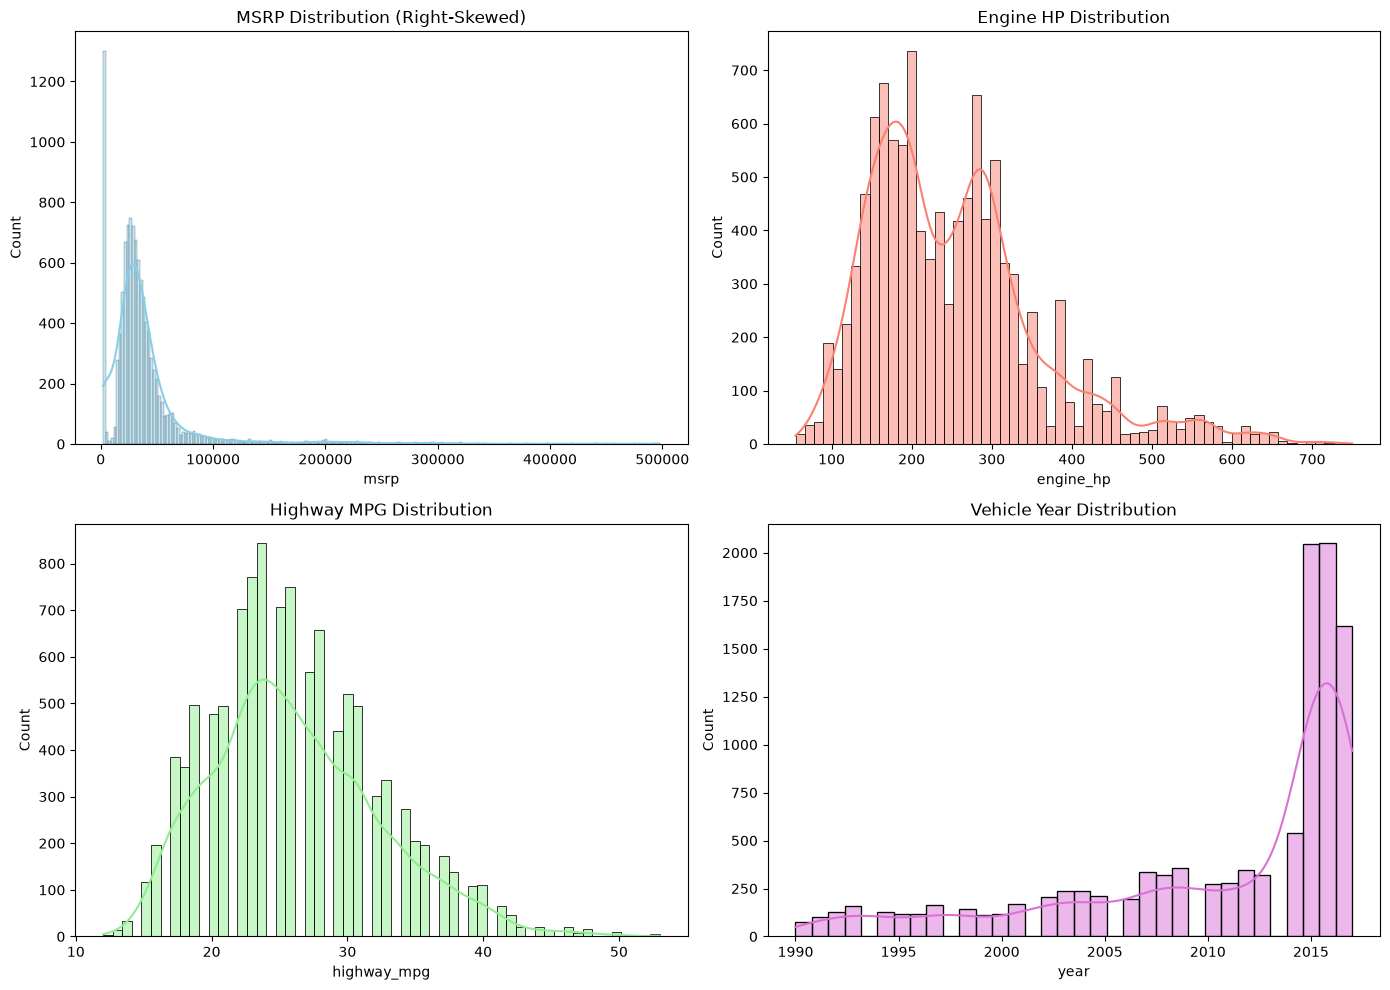

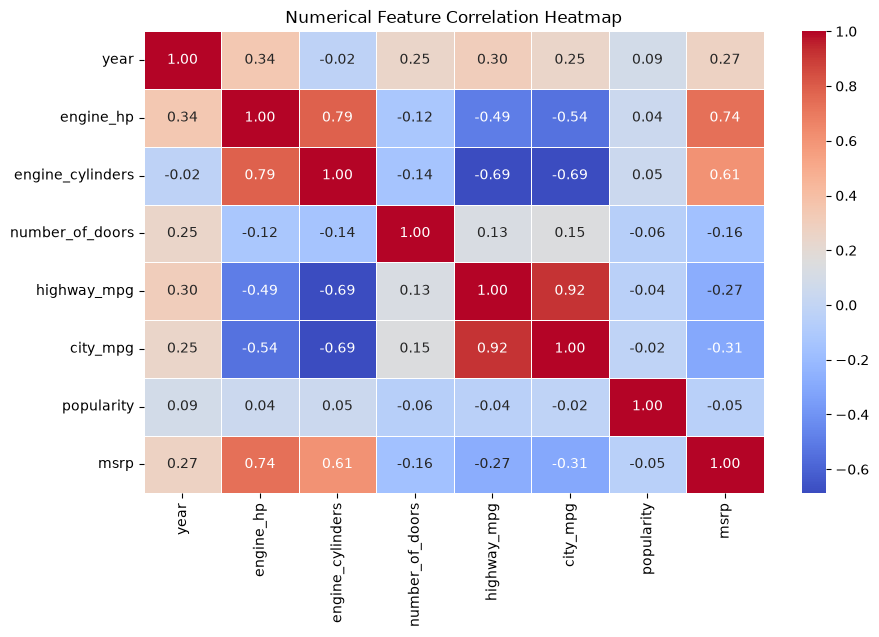

In [21]:
# 1. Distribution of Key Specs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_clean['msrp'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('MSRP Distribution (Right-Skewed)')

sns.histplot(df_clean['engine_hp'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Engine HP Distribution')

sns.histplot(df_clean['highway_mpg'], kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Highway MPG Distribution')

sns.histplot(df_clean['year'], kde=True, ax=axes[1, 1], color='orchid')
axes[1, 1].set_title('Vehicle Year Distribution')

plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
num_cols = ['year', 'engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'popularity', 'msrp']
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

#### 🎯 Selecting Features for Clustering

We explicitly define which columns go into the model, rather than 
letting the pipeline grab everything by default. This keeps us in 
control of what actually drives the clustering.

- **Excluded**: `make` (brand identity — would bias clusters toward 
  brand groupings rather than pure specs), `popularity` (measures 
  brand buzz, not a car characteristic), `model`/`market_category` 
  (already dropped earlier)
- **Numeric features**: core specs — engine, doors, MPG, price
- **Categorical features**: body/drivetrain/fuel characteristics

In [22]:
df_clean['log_msrp'] = np.log1p(df_clean['msrp'])

numeric_features = ['year', 'engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'log_msrp']
categorical_features = ['engine_fuel_type', 'transmission_type', 'driven_wheels', 'vehicle_size', 'vehicle_style']

print("Numeric features 🔢:", numeric_features)
print()
print("Categorical features 🎨:", categorical_features)
print()
print(f"Total features selected: {len(numeric_features) + len(categorical_features)} of {df.shape[1]} columns")

Numeric features 🔢: ['year', 'engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg', 'city_mpg', 'log_msrp']

Categorical features 🎨: ['engine_fuel_type', 'transmission_type', 'driven_wheels', 'vehicle_size', 'vehicle_style']

Total features selected: 12 of 16 columns


#### 🔧 Building the Preprocessing Pipeline

We construct a scikit-learn `ColumnTransformer` that:
1. Applies `StandardScaler` to numerical features (including log-transformed MSRP).
2. Applies `OneHotEncoder` to remaining categorical features (`make`, `driven_wheels`, `vehicle_size`, etc.).

In [23]:
# Create Preprocessor Pipeline
preprocessor = ColumnTransformer(
    transformers=[('num', Pipeline([('imputer', SimpleImputer(strategy='median')), 
                                    ('scaler', StandardScaler())]),numeric_features),
                  ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                                    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), categorical_features)])

# Fit & Transform Data
preprocessed_data = preprocessor.fit_transform(df_clean[numeric_features + categorical_features])
print(f"✅ Preprocessed feature matrix shape: {preprocessed_data.shape}")

✅ Preprocessed feature matrix shape: (11101, 44)


#### 📈 Elbow Method — Finding the Optimal K

The Elbow Method helps us validate our choice of K by plotting 
**inertia** (sum of squared distances from each point to its 
cluster center) against the number of clusters.

As K increases, inertia always decreases — but at some point the 
improvement becomes marginal. The "elbow" — where the curve bends 
and flattens — is the optimal K. Choosing more clusters beyond 
that point adds complexity without meaningful separation gains.

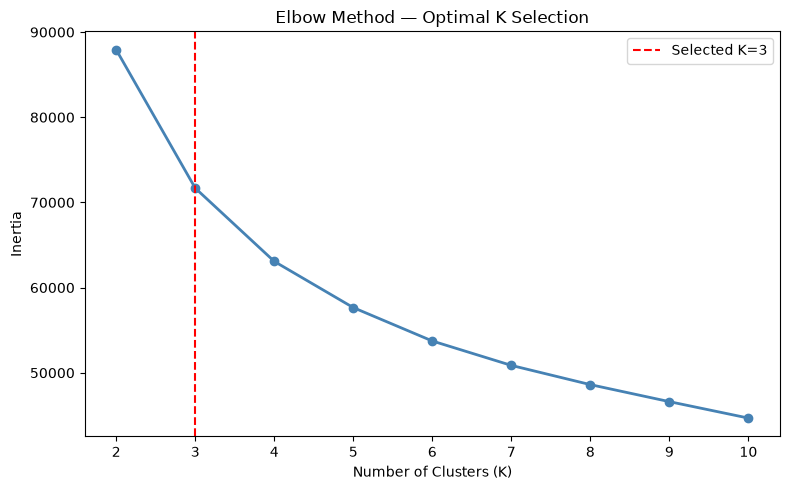

In [24]:
# ============================================================
# 📈 ELBOW METHOD
# ============================================================

inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(preprocessed_data)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K Selection')
plt.xticks(k_range)
plt.axvline(x=3, color='red', linestyle='--', label='Selected K=3')
plt.legend()
plt.tight_layout()
plt.show()

#### 📊 Silhouette Score — Validating the Optimal K

The Silhouette Score measures how well each car fits its assigned 
cluster vs how similar it is to neighboring clusters.

- Score close to **+1.0** → car is perfectly placed in its cluster
- Score close to **0.0** → car sits on the boundary between clusters
- Score close to **-1.0** → car was likely assigned to the wrong cluster

We test K from 3 to 7 and pick the K with the highest average score 
— the cleanest, most separated grouping.

K=3 → Silhouette Score: 0.2348
K=4 → Silhouette Score: 0.2219
K=5 → Silhouette Score: 0.2322
K=6 → Silhouette Score: 0.1827
K=7 → Silhouette Score: 0.1670


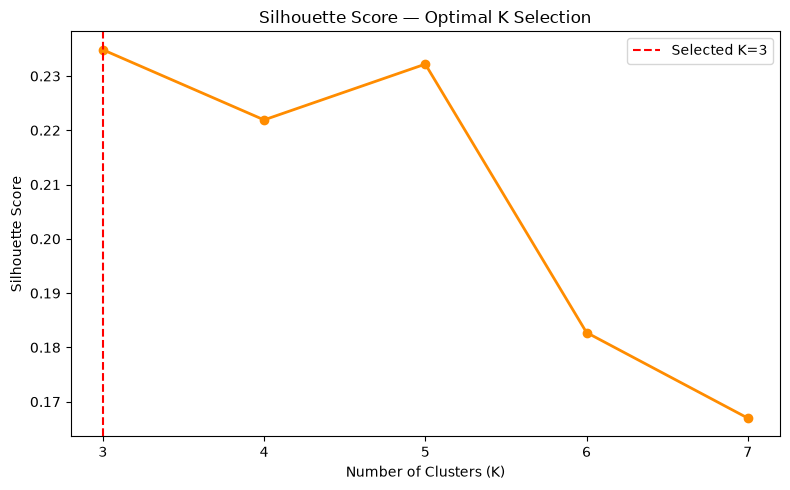

✅ Best K by Silhouette Score: 3 (score: 0.2348)


In [25]:
# ============================================================
# 📊 SILHOUETTE SCORES
# ============================================================

silhouette_scores = []
k_range           = range(3, 8)

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(preprocessed_data)
    score  = silhouette_score(preprocessed_data, labels)
    silhouette_scores.append(score)
    print(f"K={k} → Silhouette Score: {score:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='darkorange', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Optimal K Selection')
plt.xticks(k_range)
plt.axvline(x=3, color='red', linestyle='--', label='Selected K=3')
plt.legend()
plt.tight_layout()
plt.show()

best_k = k_range.start + silhouette_scores.index(max(silhouette_scores))
print(f"✅ Best K by Silhouette Score: {best_k} (score: {max(silhouette_scores):.4f})")

**What this tells us:** 3 groups produced the highest score, with 5 
groups very close behind (a difference small enough to be considered 
a near-tie). Both clearly outperform 6 and 7 groups, which score 
noticeably lower — meaning splitting the cars into that many segments 
starts breaking apart cars that are actually quite similar, making the 
groups messier rather than more insightful.


#### 🎯 Running the Final Clustering (K=3)

With **K=3** chosen (the highest-scoring option), we now run K-Means for 
real — this assigns every car in the dataset to one of 3 groups based 
on similarity across price, horsepower, MPG, and other specs.

In [26]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(preprocessed_data)

df_clean['cluster'] = cluster_labels

print("✅ Clustering complete!")
print()
print(df_clean['cluster'].value_counts().sort_index())

✅ Clustering complete!

cluster
0    4038
1    5438
2    1625
Name: count, dtype: int64


#### 🔍 Understanding What Clusters Represents

Now we look at the actual, real-world average values (price, 
horsepower, MPG) for each cluster — this is what finally tells us what 
kind of cars ended up in each group.

In [27]:
cluster_profile = df_clean.groupby('cluster')[['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'msrp']].mean().round(1)

cluster_profile['count'] = df_clean['cluster'].value_counts().sort_index()

print(cluster_profile)

         engine_hp  engine_cylinders  highway_mpg  city_mpg     msrp  count
cluster                                                                    
0            184.1               4.1         32.2      24.4  27603.2   4038
1            329.5               6.9         22.6      15.9  61242.4   5438
2            169.4               5.5         23.2      17.2   5518.4   1625


**Cluster 0 — "Efficient / Mainstream" cars:**
Lower horsepower (184), smaller engines (4 cylinders), the best fuel economy by far (32 highway MPG), and a moderate price (~$27,600). These are your everyday, practical, fuel-conscious cars — think sedans, compacts, efficient family cars.

**Cluster 1 — "High-Performance / Luxury" cars:**
Much higher horsepower (330), bigger engines (almost 7 cylinders — V6/V8 territory), worst fuel economy (only 22.6 highway MPG — makes sense, powerful engines burn more fuel), and by far the highest price (~$61,242). These are your powerful, expensive cars — sports cars, luxury vehicles, performance-oriented models.

**Cluster 2 — this one is the strange, interesting one:**
Horsepower (169) and MPG (23.2) are actually fairly similar to Cluster 0 — nothing dramatic there. But the price is wildly different: only $5,518 — dramatically cheaper than either other group, even though the specs don't look "cheap." That's the standout, defining feature of this cluster.

---

In [28]:
print(df_clean[df_clean['cluster'] == 2][['make', 'year', 'msrp', 'engine_hp']].sort_values('msrp').head(20))

                make  year  msrp  engine_hp
11477         Suzuki  1996  2000       95.0
89            Nissan  1996  2000      140.0
87            Nissan  1996  2000      115.0
63              Audi  1991  2000      162.0
62              Audi  1991  2000      217.0
61              Audi  1991  2000      217.0
60              Audi  1990  2000      162.0
184    Mercedes-Benz  1992  2000      158.0
6450          Subaru  1994  2000       90.0
6449          Subaru  1993  2000       90.0
179    Mercedes-Benz  1992  2000      177.0
6448          Subaru  1993  2000       90.0
175    Mercedes-Benz  1992  2000      121.0
174    Mercedes-Benz  1991  2000      121.0
6447          Subaru  1993  2000       90.0
29              Audi  1994  2000      172.0
28              Audi  1994  2000      172.0
167    Mercedes-Benz  1991  2000      158.0
166    Mercedes-Benz  1991  2000      177.0
6446          Subaru  1993  2000       90.0


Every car in Cluster 2 shows an MSRP of exactly **$2,000** — regardless of make or horsepower. A 1991 Mercedes-Benz with 158hp or a 1991 Audi with 217hp would never cost $2,000 in any real market. This is a **data quality artifact** — the dataset used $2,000 as a placeholder price for older cars (1990–1996) where the real MSRP was not available. Despite the unreliable pricing, these cars share a genuine characteristic: **they are all pre-1997 models**. K-Means grouped them together primarily because of their age — older engine specs, older fuel efficiency standards, and older technology naturally separate them from modern vehicles. > ⚠️ Cluster 2 is named **"Historical (Pre-1997 Models)"** — their > specs are real, but their MSRP values should not be used for any > price-based business interpretation.

#### 🔍 PCA Visualization — Seeing the Clusters in 2D

K-Means works in high-dimensional space — too many dimensions to 
visualize directly. **PCA (Principal Component Analysis)** compresses 
all features down to 2 dimensions while preserving as much variance 
as possible, letting us see the cluster separation visually.

> ⚠️ PCA is only used here for visualization — not for clustering. 
> The actual K-Means ran on the full preprocessed feature space.

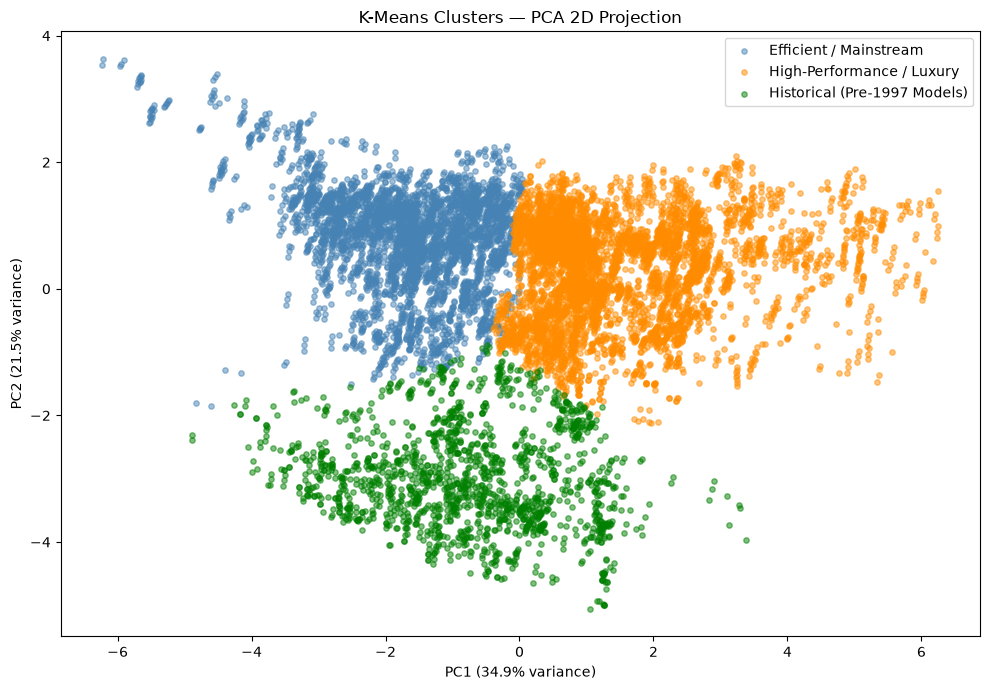

✅ PCA explains 56.4% of total variance


In [29]:
# ============================================================
# 🔍 PCA VISUALIZATION
# ============================================================

# Map cluster names if not already done
if 'cluster_name' not in df_clean.columns:
    cluster_names = {
        0: 'Efficient / Mainstream',
        1: 'High-Performance / Luxury',
        2: 'Historical (Pre-1997 Models)'
    }
    df_clean['cluster_name'] = df_clean['cluster'].map(cluster_names)

pca        = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(preprocessed_data)

plt.figure(figsize=(10, 7))

colors = {
    'Efficient / Mainstream'       : 'steelblue',
    'High-Performance / Luxury'    : 'darkorange',
    'Historical (Pre-1997 Models)' : 'green'
}

for name, color in colors.items():
    mask = df_clean['cluster_name'] == name
    plt.scatter(
        pca_coords[mask, 0],
        pca_coords[mask, 1],
        c     = color,
        label = name,
        alpha = 0.5,
        s     = 15
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters — PCA 2D Projection')
plt.legend()
plt.tight_layout()
plt.show()

print(f"✅ PCA explains {sum(pca.explained_variance_ratio_)*100:.1f}% of total variance")

**What this chart tells us:**

PC1 (34.9%) and PC2 (21.5%) together explain **56.4% of total variance** 
— meaning this 2D view captures just over half the information from 
all features. Some separation is lost in compression, which explains 
the overlapping edges between clusters.

Despite this, the three segments are clearly visible:
- 🔵 **Efficient / Mainstream** → left side, low power/price axis
- 🟠 **High-Performance / Luxury** → right side, high power/price axis  
- 🟢 **Historical (Pre-1997)** → bottom, separated by age/technology axis

The overlap between blue and orange in the center is expected — 
premium mainstream cars and entry-level luxury cars naturally share 
similar specs at the boundary. K-Means drew a mathematical line 
through a naturally continuous space.

#### 🏷️ Naming the Clusters

Now that we understand what each cluster represents, we assign 
human-readable names to each group — making the results interpretable 
for any business audience.

> ⚠️ Note: Cluster 2 groups cars manufactured before 1997. While 
> their specs are real, their MSRP values ($2,000) appear to be 
> placeholder entries rather than actual market prices — making 
> price-based interpretation of this segment unreliable.

In [30]:
# ============================================================
# 🏷️ CLUSTER NAMING
# ============================================================
cluster_names = {
    0: 'Efficient / Mainstream',
    1: 'High-Performance / Luxury',
    2: 'Historical (Pre-1997 Models)'}

df_clean['cluster_name'] = df_clean['cluster'].map(cluster_names)

print(df_clean['cluster_name'].value_counts())

cluster_name
High-Performance / Luxury       5438
Efficient / Mainstream          4038
Historical (Pre-1997 Models)    1625
Name: count, dtype: int64


#### 📊 Comparing Clusters — Primary Visualization

A bar chart comparing average horsepower and price across the 3 named 
clusters. Every value here is a real, understandable unit (horsepower, 
dollars) — this is the clearest way to see what distinguishes each 
segment.

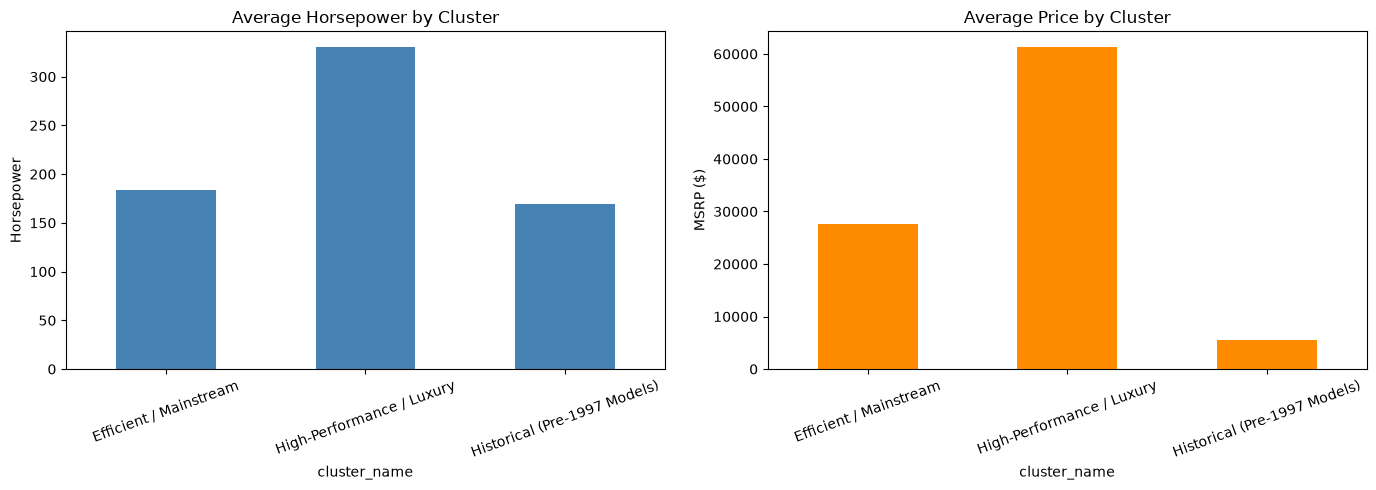

In [31]:
cluster_summary = df_clean.groupby('cluster_name')[['engine_hp', 'msrp']].mean().round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_summary['engine_hp'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Horsepower by Cluster')
axes[0].set_ylabel('Horsepower')
axes[0].tick_params(axis='x', rotation=20)

cluster_summary['msrp'].plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Average Price by Cluster')
axes[1].set_ylabel('MSRP ($)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

#### 🎨 Bonus: 3D View of the Clusters (Real Features)

An additional, optional visual — plotting horsepower, price, and 
highway MPG in 3D, colored by cluster. This isn't the primary evidence 
for our conclusions (the bar chart above is clearer for that), but it's 
a nice way to see all three clusters spread out in space using real, 
understandable features.

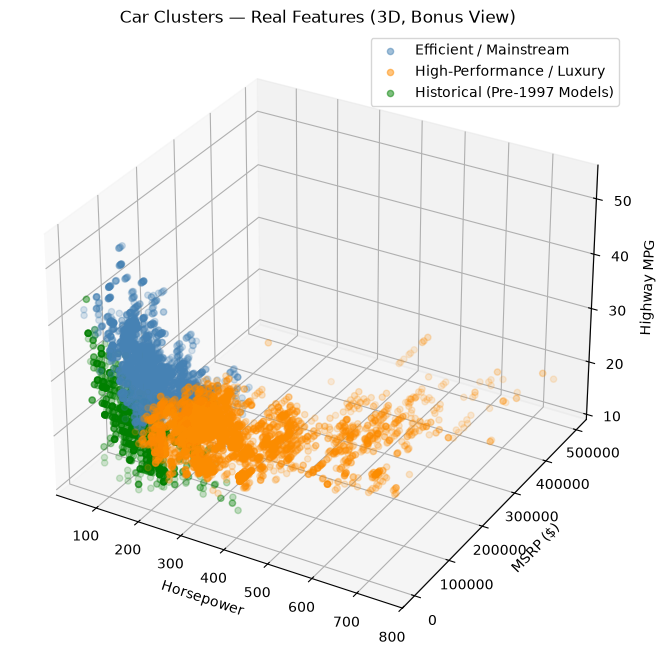

In [32]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'Efficient / Mainstream': 'steelblue', 
          'High-Performance / Luxury': 'darkorange', 
          'Historical (Pre-1997 Models)': 'green'}

for name, group in df_clean.groupby('cluster_name'):
    ax.scatter(group['engine_hp'], group['msrp'], group['highway_mpg'], 
               label=name, alpha=0.5, s=20, color=colors[name])

ax.set_xlabel('Horsepower')
ax.set_ylabel('MSRP ($)')
ax.set_zlabel('Highway MPG')
ax.set_title('Car Clusters — Real Features (3D, Bonus View)')
ax.legend()
plt.show()

#### 💾 Exporting the Final Model

We save the fitted K-Means model — including the preprocessing pipeline 
used to prepare the data — so the same clustering can be reproduced or 
applied to new cars without re-running every step manually.

In [33]:
import joblib

# Save both the preprocessor and the final K-Means model together
joblib.dump({
    'preprocessor': preprocessor,
    'kmeans_model': kmeans_final,
    'cluster_names': cluster_names
}, 'car_clustering_model.pkl')

print("✅ Model exported successfully to 'car_clustering_model.pkl'")
print(f"   Contains: preprocessing pipeline + K-Means (K=3) + cluster name mapping")

✅ Model exported successfully to 'car_clustering_model.pkl'
   Contains: preprocessing pipeline + K-Means (K=3) + cluster name mapping


In [34]:
loaded = joblib.load('car_clustering_model.pkl')
print(loaded.keys())

dict_keys(['preprocessor', 'kmeans_model', 'cluster_names'])


### 📌 Executive Summary & Conclusion

#### 🎯 Project Overview
This project segments ~11,000 U.S. car models (1990–2018) into natural 
market groups using **K-Means clustering** — an unsupervised approach 
with no predefined categories and no target variable to predict. Rather 
than imposing labels like "economy" or "luxury" in advance, the goal 
was to let the data reveal its own structure, then interpret what that 
structure means.

---

#### 📊 Results — 3 Market Segments

| Cluster | Avg. HP | Cylinders | Highway MPG | City MPG | Avg. MSRP | Count |
|---|---|---|---|---|---|---|
| Efficient / Mainstream | 184 | 4.1 | 32.2 | 24.4 | $27,603 | 4,038 |
| High-Performance / Luxury | 330 | 6.9 | 22.6 | 15.9 | $61,242 | 5,438 |
| Historical (Pre-1997 Models) | 169 | 5.5 | 23.2 | 17.2 | $5,518 | 1,625 |

- **Efficient / Mainstream** — practical, fuel-conscious cars: best fuel 
  economy of the three segments, moderate price
- **High-Performance / Luxury** — the most powerful and expensive 
  segment by a wide margin, trading off fuel economy for performance
- **Historical (Pre-1997 Models)** — its low price reflects model year, 
  not a deliberate "budget" design — this was confirmed by inspecting 
  the actual years within the cluster before naming it, rather than 
  assuming from price alone

---
#### 📝**Note**:  
**Choosing K via Silhouette Score** — tested K=3 through K=7; 
  K=3 scored highest (0.235), clearly ahead of K=6/K=7, and only marginally ahead of K=5. K=3 was selected as the clearer, top-scoring, and simplest-to-interpret choice.

   A Silhouette Score of 0.235 indicates weak-to-moderate cluster 
   separation — the segments are statistically the best available 
   option among those tested, but the underlying structure isn't 
   strongly distinct. This is a realistic outcome given how continuous 
   and overlapping real-world car specs tend to be, rather than a flaw 
   in the methodology.

---

#### 🔑 Key Modeling Decisions

1. **Outlier correction** — identified and removed a data entry error 
   (an Audi listed at 354 highway MPG, physically implausible for a 
   gas-powered vehicle).
2. **Log-transformed MSRP** — reduced the distorting influence of a 
   small number of multi-million-dollar hypercars (e.g., Bugatti Veyron 
   at $2M+) on K-Means' distance calculations.
3. **Deliberate feature exclusions** — `make` and `popularity` were left 
   out of clustering, to avoid grouping cars by brand identity or 
   brand-buzz rather than by their actual specifications.
4. **Choosing K via Silhouette Score** — tested K=3 through K=7; K=3 
   scored highest (0.235), clearly ahead of K=6/K=7, and only 
   marginally ahead of K=5. K=3 was selected as the clearer, 
   top-scoring, and simplest-to-interpret choice.

---

#### ⚠️ Key Limitation

Cluster labels are a human interpretation applied *after* clustering — 
K-Means itself only outputs group numbers (0, 1, 2), with no inherent 
meaning attached. Each label in this project was derived by comparing 
real feature averages across clusters (not the compressed PCA 
visualization, which was excluded from the final analysis for being 
difficult to interpret meaningfully). Where a cluster's story wasn't 
immediately obvious — the low-price cluster — the underlying data was 
inspected directly before finalizing a name, rather than guessing from 
price alone.

More broadly, K-Means assumes clusters are roughly round/similarly 
sized, which may not perfectly reflect how real car segments are 
shaped in the underlying feature space — a limitation worth exploring 
with alternative methods.

---

#### 🚧 Future Work

- Re-run clustering with `make` included, to test whether brand-driven 
  segments reveal additional insight beyond specs alone
- Explore **DBSCAN** as a density-based alternative that doesn't 
  require pre-specifying K, and can explicitly flag outlier vehicles 
  as noise rather than forcing them into a cluster
- Test whether a 4- or 5-cluster solution becomes more competitive 
  under different feature or preprocessing choices, since K=3 and K=5 
  were nearly tied on Silhouette Score